# Physics-Informed Machine Learning for Vehicle Dynamics
**System Identification of GT3 and GT4 Race Cars using PySINDy**

This notebook demonstrates the extraction of vehicle dynamics governing equations (ODEs) directly from Assetto Corsa Competizione (ACC) telemetry data. We compare two distinct vehicle classes to validate the model's robustness:
* **GT3:** Lamborghini Huracán GT3 Evo2 @ Nürburgring (High aerodynamic reliance, bumpy track surface)
* **GT4:** Porsche 718 Cayman GT4 @ Red Bull Ring (Mechanical grip reliance, smooth track surface, ideal traction without tire wear/fuel weight degradation)

The project progresses through three stages of physical and mathematical refinement:
1.  **Baseline:** Raw data regression (The noise trap)
2.  **Signal Processing:** Savitzky-Golay filtering (Addressing high-frequency sensor noise)
3.  **Physics Injection:** edit SINDy Library with more likely appeared physical terms. 

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
os.chdir('..')
import src.process_data
import src.run_sindy
import pysindy as ps

## Stage 1: The Baseline (Raw Data Regression)
**Objective:** Apply standard SINDy to raw 200Hz telemetry data using finite difference derivatives.

**Hypothesis:** High-frequency noise from track bumps (especially at Nürburgring) and gear shifts will heavily distort the numerical differentiation, leading to poor model performance and unphysical polynomial terms.

### GT3:

In [2]:
GT3_raw_data = src.process_data.load_raw_motec_data("data/nurburgring-lamborghini_huracan_gt3_evo2-21-2026.02.17-18.40.csv")
src.run_sindy.run_sindy_analysis(GT3_raw_data)

read the file: data/nurburgring-lamborghini_huracan_gt3_evo2-21-2026.02.17-18.40.csv ...
Using column 'Time' as time axis.
pySINDy is running：

var:
--- IV (x) ---
x0 -> SPEED
x1 -> G_LAT
x2 -> G_LON
x3 -> ROTY
--- DV (u) ---
u0 -> STEERANGLE
u1 -> THROTTLE
u2 -> BRAKE

recognized functions:
(x0)' = -2.235 1 +  0.072 x0 + -0.375 x1 +  2.900 x2 +  0.081 x3 +  0.054 u0 +  0.082 u1 + -0.078 u2 + -0.002 x0^2 +  0.012 x0 x1 + -0.082 x0 x2 + -0.029 x0 x3 +  0.012 x0 u0 +  0.001 x0 u1 + -0.001 x0 u2 + -0.603 x1^2 +  0.207 x1 x2 +  2.964 x1 x3 + -0.446 x1 u0 + -0.003 x1 u1 +  0.015 x1 u2 +  1.504 x2^2 + -0.704 x2 x3 +  0.390 x2 u0 +  0.001 x2 u1 +  0.085 x2 u2 + -9.839 x3^2 +  3.914 x3 u0 +  0.026 x3 u1 + -0.042 x3 u2 + -0.320 u0^2 + -0.008 u0 u1 +  0.008 u0 u2 + -0.001 u1 u2 +  0.001 u2^2
(x1)' = -0.090 1 +  0.009 x0 + -1.452 x1 + -0.372 x2 + -7.347 x3 +  0.183 u0 + -0.004 u1 + -0.019 u2 + -0.043 x0 x1 + -0.002 x0 x2 +  0.449 x0 x3 +  0.026 x0 u0 + -0.333 x1^2 + -0.588 x1 x2 +  1.747 x1 x3 + 

(SINDy(differentiation_method=FiniteDifference(),
       feature_library=PolynomialLibrary(), optimizer=STLSQ(threshold=0.0001)),
 0.15453148691107862)

### GT4

In [3]:
GT4_raw_data = src.process_data.load_raw_motec_data("data/red_bull_ring-porsche_718_cayman_gt4_mr-15-2026.01.04-22.28.csv")
src.run_sindy.run_sindy_analysis(GT4_raw_data)

read the file: data/red_bull_ring-porsche_718_cayman_gt4_mr-15-2026.01.04-22.28.csv ...
Using column 'Time' as time axis.
pySINDy is running：

var:
--- IV (x) ---
x0 -> SPEED
x1 -> G_LAT
x2 -> G_LON
x3 -> ROTY
--- DV (u) ---
u0 -> STEERANGLE
u1 -> THROTTLE
u2 -> BRAKE

recognized functions:
(x0)' = -7.400 1 +  0.250 x0 +  0.635 x1 +  1.341 x2 + -4.821 x3 + -1.130 u0 +  0.084 u1 + -0.098 u2 + -0.002 x0^2 + -0.018 x0 x1 + -0.003 x0 x2 +  0.166 x0 x3 +  0.021 x0 u0 + -0.001 x0 u1 + -1.273 x1^2 +  1.157 x1 x2 +  9.669 x1 x3 + -1.169 x1 u0 + -0.002 x1 u1 +  0.022 x1 u2 +  1.044 x2^2 + -8.904 x2 x3 +  2.713 x2 u0 + -0.008 x2 u1 +  0.040 x2 u2 + -11.507 x3^2 + -1.037 x3 u0 +  0.001 x3 u1 + -0.141 x3 u2 +  0.481 u0^2 +  0.005 u0 u1 + -0.004 u0 u2 + -0.001 u1 u2
(x1)' = -1.908 1 +  0.055 x0 + -5.301 x1 + -0.119 x2 +  10.664 x3 + -4.314 u0 +  0.021 u1 +  0.011 u2 +  0.012 x0 x1 +  0.009 x0 x2 +  0.176 x0 x3 +  0.138 x0 u0 + -0.001 x0 u1 + -0.099 x1^2 +  0.048 x1 x2 + -4.766 x1 x3 +  1.612 x1 u0 

(SINDy(differentiation_method=FiniteDifference(),
       feature_library=PolynomialLibrary(), optimizer=STLSQ(threshold=0.0001)),
 0.26832679291581707)

## Stage 2: Signal Processing (Savitzky-Golay Filtering)
**Objective:** Address the R^2 degradation caused by numerical noise amplification. 

**Methodology:** Instead of standard finite difference or basic Gaussian smoothing (which flattens physical peaks like curb strikes), we apply a Savitzky-Golay filter. This local polynomial regression preserves the width and height of dynamic peaks while allowing us to compute exact, smoothed temporal derivatives ($\dot{x}$) analytically.

*Result:* We expect a significant jump in physical accuracy and R^2, with the smoother GT4 data showing more dramatic improvement.

### GT3

In [4]:
GT3_SG_data = src.process_data.apply_savgol_filter(GT3_raw_data)
GT3_SG_model, GT3_SG_score = src.run_sindy.run_sindy_analysis(GT3_SG_data)

Applying Savitzky-Golay filter (Window=21, Poly=3) to columns: ['STEERANGLE', 'THROTTLE', 'BRAKE', 'SPEED', 'G_LAT', 'G_LON', 'ROTY']


Using column 'Time' as time axis.
pySINDy is running：

var:
--- IV (x) ---
x0 -> SPEED
x1 -> G_LAT
x2 -> G_LON
x3 -> ROTY
--- DV (u) ---
u0 -> STEERANGLE
u1 -> THROTTLE
u2 -> BRAKE

recognized functions:
(x0)' = -2.206 1 +  0.074 x0 + -0.360 x1 +  2.766 x2 + -0.105 x3 +  0.115 u0 +  0.079 u1 + -0.084 u2 + -0.002 x0^2 +  0.012 x0 x1 + -0.081 x0 x2 + -0.026 x0 x3 +  0.011 x0 u0 +  0.001 x0 u1 + -0.001 x0 u2 + -0.631 x1^2 +  0.304 x1 x2 +  3.078 x1 x3 + -0.452 x1 u0 + -0.004 x1 u1 +  0.015 x1 u2 +  1.362 x2^2 + -0.679 x2 x3 +  0.261 x2 u0 +  0.004 x2 u1 +  0.087 x2 u2 + -10.127 x3^2 +  3.994 x3 u0 +  0.028 x3 u1 + -0.039 x3 u2 + -0.321 u0^2 + -0.008 u0 u1 +  0.006 u0 u2 + -0.001 u1 u2 +  0.001 u2^2
(x1)' = -0.179 1 +  0.013 x0 + -1.292 x1 + -0.614 x2 + -8.737 x3 +  0.458 u0 + -0.004 u1 + -0.024 u2 + -0.049 x0 x1 +  0.002 x0 x2 +  0.490 x0 x3 +  0.020 x0 u0 + -0.375 x1^2 + -0.793 x1 x2 +  1.945 x1 x3 + -0.285 x1 u0 + -0.004 x1 u1 +  0.005 x1 u2 +  0.402 x2^2 + -0.541 x2 x3 +  0.875 x2 u0 +

### GT4

In [5]:
GT4_SG_data = src.process_data.apply_savgol_filter(GT4_raw_data)
GT4_SG_model, GT4_SG_score = src.run_sindy.run_sindy_analysis(GT4_SG_data)

Applying Savitzky-Golay filter (Window=21, Poly=3) to columns: ['STEERANGLE', 'THROTTLE', 'BRAKE', 'SPEED', 'G_LAT', 'G_LON', 'ROTY']
Using column 'Time' as time axis.
pySINDy is running：

var:
--- IV (x) ---
x0 -> SPEED
x1 -> G_LAT
x2 -> G_LON
x3 -> ROTY
--- DV (u) ---
u0 -> STEERANGLE
u1 -> THROTTLE
u2 -> BRAKE

recognized functions:
(x0)' = -7.310 1 +  0.241 x0 +  0.529 x1 +  2.059 x2 + -5.399 x3 + -0.737 u0 +  0.085 u1 + -0.083 u2 + -0.002 x0^2 + -0.017 x0 x1 +  0.003 x0 x2 +  0.180 x0 x3 +  0.012 x0 u0 + -0.001 x0 u1 + -1.487 x1^2 +  1.298 x1 x2 +  11.546 x1 x3 + -1.506 x1 u0 + -0.003 x1 u1 +  0.024 x1 u2 +  0.740 x2^2 + -11.710 x2 x3 +  3.367 x2 u0 + -0.015 x2 u1 +  0.028 x2 u2 + -14.465 x3^2 + -0.587 x3 u0 +  0.008 x3 u1 + -0.177 x3 u2 +  0.612 u0^2 +  0.004 u0 u1 +  0.008 u0 u2
(x1)' = -1.790 1 +  0.042 x0 + -5.731 x1 +  0.008 x2 +  11.128 x3 + -4.385 u0 +  0.025 u1 +  0.016 u2 +  0.019 x0 x1 +  0.007 x0 x2 +  0.185 x0 x3 +  0.139 x0 u0 + -0.001 x0 u1 + -0.128 x1^2 + -0.435 x1 

请求积分帧数: 300


/home/ubuntu/miniforge3/envs/dev/lib/python3.10/site-packages/pysindy/_core.py:621: UserWarning: Last time point dropped in simulation because interpolation of control input was used. To avoid this, pass in a callable for u.
  warnings.warn(


Valid Frames: 299
⚠️ at 299 frames, ODE integration failed to continue.
-> trace before crash...


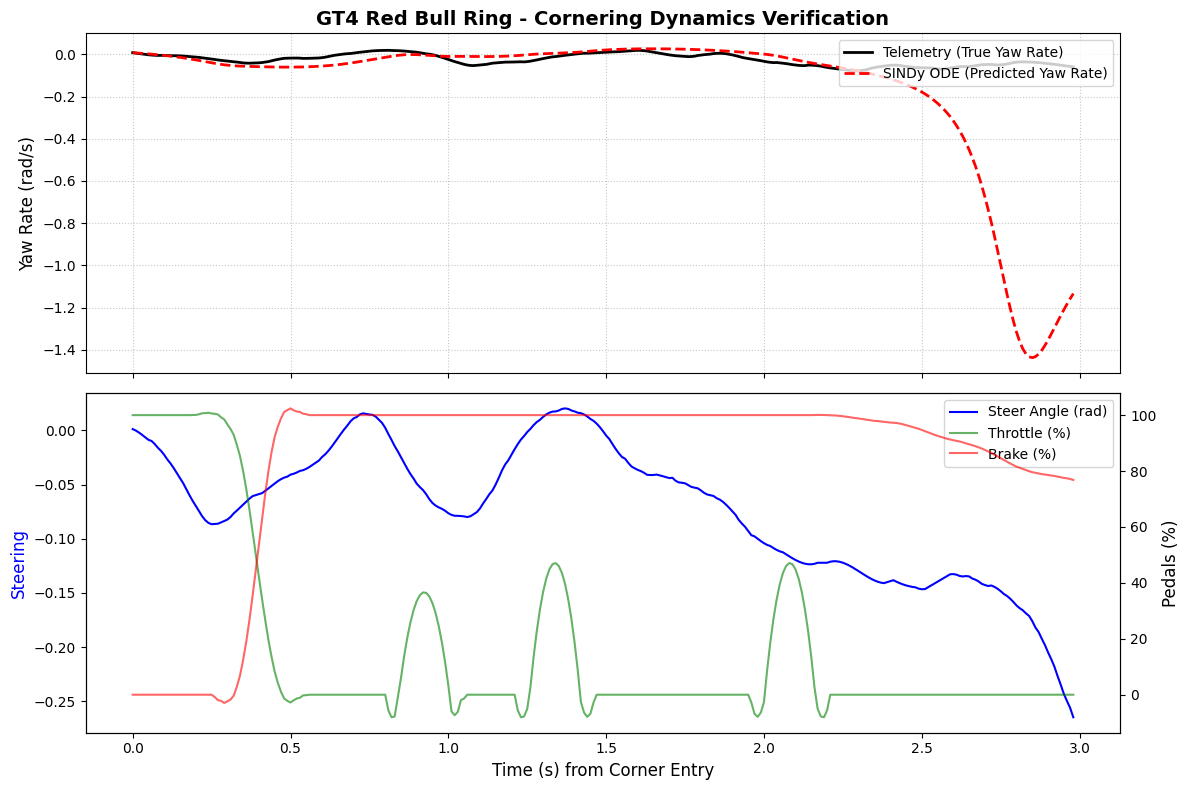

In [ ]:
from src.visualizer import plot_corner_dynamics

peak_brake_idx = GT4_SG_data['BRAKE'].idxmax()

start_idx = peak_brake_idx - 50
end_idx = peak_brake_idx + 250

corner_data = GT4_SG_data.iloc[start_idx:end_idx].copy()
t_corner = corner_data['Time'].values - corner_data['Time'].values[0]
x0 = corner_data[['SPEED', 'G_LAT', 'G_LON', 'ROTY']].values[0]
u_input = corner_data[['STEERANGLE', 'THROTTLE', 'BRAKE']].values

print(f"Total Frames: {len(t_corner)}")


X_pred = GT4_SG_model.simulate(
    x0, 
    t=t_corner, 
    u=u_input, 
    integrator="odeint", 
    integrator_kws={"rtol": 1e-4, "atol": 1e-4}
)


valid_len = X_pred.shape[0]
print(f"Valid Frames: {valid_len}")

if valid_len < len(t_corner):
    print(f"⚠️ at {valid_len} frames, ODE integration failed to continue.")
    print("-> trace before crash...")
    
    corner_data = corner_data.iloc[:valid_len].copy()


plot_corner_dynamics(corner_data, X_pred, title_prefix="GT4 Red Bull Ring")